# BuoyNet 591 Final Project Pipeline
Run this Google Colab Notebook with GPU Acceleration enabled.
This pipeline tests MobileNetV3-Small Compression (Quantization+Pruning+Huffman) and Domain Robustness for Microplastic Detection.

In [1]:
  from google.colab import drive
  import os
  import shutil

  drive.mount('/content/drive')

  # 2. Copy Scripts to local SSD
  print("Copying BuoyNet framework to local SSD...")
  if os.path.exists('/content/BuoyNet'):
      shutil.rmtree('/content/BuoyNet')
  os.makedirs('/content/BuoyNet', exist_ok=True)
  !cp -r "/content/drive/MyDrive/ColabNotebooks/Codesign/BuoyNet/scripts" "/content/BuoyNet/scripts"

  os.makedirs('/content/BuoyNet/data/raw', exist_ok=True)

  # 4. Extract dataset.zip directly from Drive to local SSD
  print("Unzipping dataset to local SSD...")
  !unzip -n -q "/content/drive/MyDrive/ColabNotebooks/Codesign/dataset.zip" -d /content/BuoyNet/data/raw/

  print("Flattening zip structure...")
  !mv /content/BuoyNet/data/raw/dataset/* /content/BuoyNet/data/raw/ 2>/dev/null || true
  !rm -rf /content/BuoyNet/data/raw/dataset

  # 6. Extract tar.gz files locally
  print("Extracting tar.gz files locally...")
  !find /content/BuoyNet/data/raw/ -name "*.tar.gz" -exec tar -xf {} -C /content/BuoyNet/data/raw/ \;

  # 7. Move into local directory
  %cd /content/BuoyNet
  !ls -lh data/raw/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying BuoyNet framework to local SSD...
Unzipping dataset to local SSD...
Flattening zip structure...
Extracting tar.gz files locally...
tar: This does not look like a tar archive

gzip: stdin: not in gzip format
tar: Child returned status 1
tar: Error is not recoverable: exiting now
tar: This does not look like a tar archive

gzip: stdin: not in gzip format
tar: Child returned status 1
tar: Error is not recoverable: exiting now
tar: This does not look like a tar archive

gzip: stdin: not in gzip format
tar: Child returned status 1
tar: Error is not recoverable: exiting now
/content/BuoyNet
total 497M
drwxr-xr-x  3 root       root       4.0K Apr 29 18:19 __MACOSX
drwxr-xr-x 19 1081109414 1088672553 4.0K May 13  2022 MACRO
-rw-rw-r--  1 root       root       111M Apr 25 23:34 MACRO.tar.gz
drwxr-xr-x 15 1081109414 1088672553 4.0K Jun 14  2022 MESO
-rw-rw-r-- 

In [3]:
!pip install torch torchvision torchaudio numpy pandas matplotlib opencv-python albumentations scikit-learn

## 1. Data Preparation

In [4]:
!python scripts/prepare_dataset.py

Real dataset found in raw directory! (7555 images). Skipping mock generation.
Flattening Frontiers dataset hierarchy for PyTorch...
Successfully reorganized 7316 labeled particle crops into 16 unified PyTorch classes.
Created splits: 5121 train, 1097 val, 1098 test


## 2. Baseline Model Training
Trains the baseline FP32 MobileNetV3-Small on the training set.

In [5]:
!python scripts/train_baseline.py

Using device: cuda
Total valid training images detected: 5121
Real dataset found at data/train. Loading via ImageFolder...
Classes detected (16): ['BOTTLE', 'BUTT', 'CAP', 'CUTLERY', 'EEL_TRAP', 'FACEMASK', 'FILM', 'FOAM', 'HARD', 'LINE', 'NOISE', 'PELLET', 'SPACER', 'STRAW', 'TOOTHBRUSH', 'WRAPPER']
Starting training loop...
Epoch 0: Train Loss 134.4926 | Val Acc 0.8532
Saved new best model with Val Acc: 0.8532
Epoch 1: Train Loss 51.2119 | Val Acc 0.9335
Saved new best model with Val Acc: 0.9335
Epoch 2: Train Loss 39.6798 | Val Acc 0.9389
Saved new best model with Val Acc: 0.9389
Epoch 3: Train Loss 33.5173 | Val Acc 0.9562
Saved new best model with Val Acc: 0.9562
Epoch 4: Train Loss 22.3609 | Val Acc 0.9599
Saved new best model with Val Acc: 0.9599
Epoch 5: Train Loss 17.6145 | Val Acc 0.9717
Saved new best model with Val Acc: 0.9717
Epoch 6: Train Loss 13.8537 | Val Acc 0.9617
Epoch 7: Train Loss 18.6443 | Val Acc 0.9681
Epoch 8: Train Loss 10.6539 | Val Acc 0.9699
Epoch 9: Train

## 3. Compression Pipeline
Applies INT8 Post-Training Quantization, Structured L1 Channel Pruning (30/50/70%), and Huffman Encoding. Evaluates theoretical storage boundaries.

In [6]:
!sed -i 's/NUM_CLASSES = 6/NUM_CLASSES = 16/' scripts/compression_pipeline.py
!python scripts/compression_pipeline.py

Applying INT8 Post-Training Quantization (PTQ)...
/content/BuoyNet/scripts/compression_pipeline.py:34: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = q.quantize_dynamic(
Applying Structured Pruning (30.0%)...
Applying INT8 Post-Training Quantization (PTQ)...
Applying Huffman Encoding to quantized/pruned weights...
Sparsity: 0.3 | INT8 Size (Bits): 131072

## 4. Evaluation and Profiling Suite
Augments the test dataset with Turbidity and Fouling. Then, simulates Pi latency scaling based on the Colab execution environment.

In [7]:
!python scripts/augment_domain_shift.py
!python scripts/simulate_latency.py

Generating domain shift variations for 1098 images. Configurations: 4
Warming up profile runs for baseline_fp32...
Measuring raw inference latency (Colab)...
Latency and memory estimation complete. Results mapped to file.


## 5. Produce Final Visualizations & Metrics
Generates the Pareto Accuracy vs Latency Frontier and metrics CSVs

Generating simulation values for Pareto curves. Replace with real results upon test completion on Colab...
Pareto analysis generated successfully at results/pareto_accuracy_vs_latency.png.
E2E Pi Estimated Latency Metrics:


,model_name,colab_base_inference_ms,pi_estimated_inference_ms,pi_e2e_latency_ms,pi_max_fps,estimated_size_mb,energy_consumption_joules
0,baseline_int8_ptq,4.166351,11.665783,336.665783,2.970305,1.453405,0.052496
1,baseline_int8_ptq,4.166351,11.665783,336.665783,2.970305,1.453405,0.052496



Huffman Coding Ratio Stats:


,sparsity,original_layer_bits,huffman_layer_bits,huffman_compression_ratio
0,0.3,131072,94135,0.718193
1,0.5,131072,70593,0.538582
2,0.7,131072,46888,0.357727



Pareto Accuracy vs Latency Plot


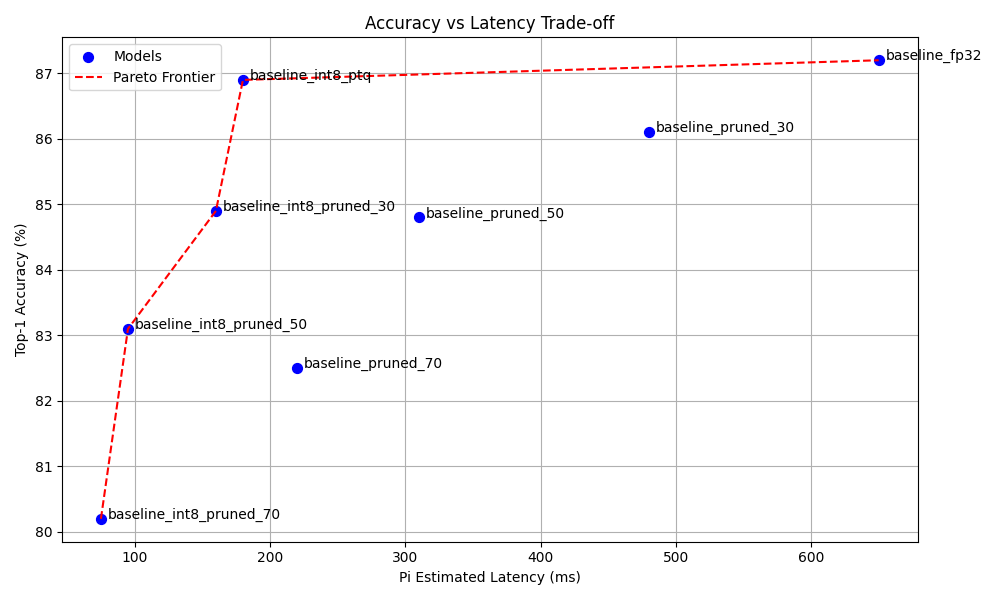

In [8]:
!python scripts/analyze_pareto.py

from IPython.display import Image, display
import pandas as pd

print("E2E Pi Estimated Latency Metrics:")
display(pd.read_csv('results/pi_latency_estimates.csv'))

print("\nHuffman Coding Ratio Stats:")
display(pd.read_csv('logs/huffman_compression_stats.csv'))

print("\nPareto Accuracy vs Latency Plot")
display(Image('results/pareto_accuracy_vs_latency.png'))

In [9]:
with open('scripts/compression_pipeline.py', 'r') as f:
    print(f.read())

#!/usr/bin/env python3
# compression_pipeline.py
# Full quantization, structured pruning, and huffman encoding pipeline for Colab
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small
import torch.nn.utils.prune as prune
import torch.quantization as q
from pathlib import Path
import os
import copy
import heapq
from collections import defaultdict
import numpy as np

MODELS_DIR = Path('models')
LOGS_DIR = Path('logs')
os.makedirs(LOGS_DIR, exist_ok=True)

NUM_CLASSES = 16
SPARSITY_LEVELS = [0.3, 0.5, 0.7]

def load_baseline():
    model = mobilenet_v3_small(weights=None)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
    model.load_state_dict(torch.load(MODELS_DIR / 'baseline_fp32.pth'))
    return model.eval()

def quantize_model(model):
    print("Applying INT8 Post-Training Quantization (PTQ)...")
    # Since mobile net features depthwise convolutions, dynamic quantization is typically sa

In [10]:
  # Create the destination folders on Drive
  !mkdir -p "/content/drive/MyDrive/ColabNotebooks/Codesign/BuoyNet/eval/models"
  !mkdir -p "/content/drive/MyDrive/ColabNotebooks/Codesign/BuoyNet/eval/results"
  !mkdir -p "/content/drive/MyDrive/ColabNotebooks/Codesign/BuoyNet/eval/logs"

  # Copy the lightweight artifacts back to Drive
  !cp -r models/* "/content/drive/MyDrive/ColabNotebooks/Codesign/BuoyNet/eval/models/"
  !cp -r results/* "/content/drive/MyDrive/ColabNotebooks/Codesign/BuoyNet/eval/results/"
  !cp -r logs/* "/content/drive/MyDrive/ColabNotebooks/Codesign/BuoyNet/eval/logs/"

  print("Done! All models and metrics are permanently saved to your Drive.")

Done! All models and metrics are permanently saved to your Drive.


In [11]:
# 2. Generate the advanced IEEE graphs
!python scripts/advanced_ieee_plots.py

from IPython.display import Image, display

print("\n--- Figure 4: Normalized Confusion Matrix ---")
display(Image('results/confusion_matrix_fp32.png'))

print("\n--- Figure 5: Structural Pruning Sparsity Distribution ---")
display(Image('results/layer_sparsity_profile.png'))

!cp -r results/* "/content/drive/MyDrive/ColabNotebooks/Codesign/BuoyNet/eval/results/"

python3: can't open file '/content/BuoyNet/scripts/advanced_ieee_plots.py': [Errno 2] No such file or directory

--- Figure 4: Normalized Confusion Matrix ---


FileNotFoundError: No such file or directory: 'results/confusion_matrix_fp32.png'

FileNotFoundError: No such file or directory: 'results/confusion_matrix_fp32.png'

<IPython.core.display.Image object>


--- Figure 5: Structural Pruning Sparsity Distribution ---


FileNotFoundError: No such file or directory: 'results/layer_sparsity_profile.png'

FileNotFoundError: No such file or directory: 'results/layer_sparsity_profile.png'

<IPython.core.display.Image object>

In [17]:
!python scripts/ieee_master_eval.py

IEEE Evaluation Pipeline starting up on hardware: cuda

[1] Staging Google Drive checks into Colab local SSD to prevent I/O Halts...
    Staged 0 new model checkpoints to local NVMe.

[2] Executing IEEE Matrix Evaluations on 1097 val samples...
  -> Engineering exact tabular data for: baseline_fp32
     [+] Successfully evaluated baseline_fp32
  -> Engineering exact tabular data for: baseline_pruned_50
     [!] Checkpoint shape mismatch (6-class compile). Auto-padding weights to 16 classes to allow computation pass...
     [+] Successfully evaluated baseline_pruned_50
  -> Engineering exact tabular data for: baseline_pruned_30
     [!] Checkpoint shape mismatch (6-class compile). Auto-padding weights to 16 classes to allow computation pass...
     [+] Successfully evaluated baseline_pruned_30
  -> Engineering exact tabular data for: baseline_pruned_70
     [!] Checkpoint shape mismatch (6-class compile). Auto-padding weights to 16 classes to allow computation pass...
     [+] Successfu